# Lecture 4 — Extracting events and phase from data


In [1]:
# Housekeeping code...
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import linear_sum_assignment
from scipy.signal import (
    correlate,
    correlation_lags,
    find_peaks,
    hilbert,
    savgol_filter,
)
from IPython.display import Video, display

if Path("../media").exists():
    MEDIA = Path("../media")
    MOUSE_DATA = Path("../data/mouse")
elif Path("media").exists():
    MEDIA = Path("media")
    MOUSE_DATA = Path("data/mouse")
else:
    raise FileNotFoundError("Run this notebook from the course repository.")

FIREFLY_DISPLAY_VIDEO = MEDIA / "firefly-synchrony.mp4"
FIREFLY_ANALYSIS_VIDEO = MEDIA / "firefly-synchrony-analysis.mp4"
LEAP_VIDEO = MEDIA / "leap-fly-pose-tracking.mp4"
MOUSE_VIDEO = MEDIA / "mouse-running.mp4"
MOUSE_FPS = 80.0
TAU = 2 * np.pi

BLUE = "#3B6FB6"
ORANGE = "#D97706"
GOLD = "#C9A227"
PINK = "#B64E77"
OLIVE = "#718355"
INK = "#263238"
GREY = "#9AA0A6"
LIGHT = "#E7EAED"
LIMB_COLORS = {"LF": BLUE, "RF": ORANGE, "RH": OLIVE, "LH": PINK}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
})

def movie(path, width=760):
    return Video(
        str(path),
        embed=False,
        width=width,
        html_attributes="controls loop muted playsinline",
    )

def video_properties(path):
    capture = cv2.VideoCapture(str(path))
    if not capture.isOpened():
        raise FileNotFoundError(path)
    properties = {
        "fps": capture.get(cv2.CAP_PROP_FPS),
        "n_frames": int(capture.get(cv2.CAP_PROP_FRAME_COUNT)),
        "width": int(capture.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    capture.release()
    return properties

def read_rgb_frame(path, frame_index):
    capture = cv2.VideoCapture(str(path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame_bgr = capture.read()
    capture.release()
    if not ok:
        raise IndexError(f"Could not read frame {frame_index} from {path}")
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

def detect_frame(rgb_frame, threshold=20, min_area=5):
    gray = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2GRAY)
    mask = (gray > threshold).astype(np.uint8)
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask, connectivity=8
    )

    rows = []
    for label in range(1, n_labels):
        area = int(stats[label, cv2.CC_STAT_AREA])
        if area < min_area:
            continue
        x_px, y_px = centroids[label]
        integrated_intensity = int(gray[labels == label].sum())
        rows.append({
            "label": label,
            "x_px": x_px,
            "y_px": y_px,
            "intensity": integrated_intensity,
            "area": area,
        })
    return gray, mask, labels, pd.DataFrame(rows)

def detect_movie(path, threshold=20, min_area=5):
    properties = video_properties(path)
    capture = cv2.VideoCapture(str(path))
    rows = []
    frame_index = 0

    while True:
        ok, frame_bgr = capture.read()
        if not ok:
            break
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        mask = (gray > threshold).astype(np.uint8)
        n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            mask, connectivity=8
        )

        for label in range(1, n_labels):
            area = int(stats[label, cv2.CC_STAT_AREA])
            if area < min_area:
                continue
            x_px, y_px = centroids[label]
            rows.append({
                "x_px": x_px,
                "y_px": y_px,
                "frame": frame_index,
                "time_s": frame_index / properties["fps"],
                "intensity": int(gray[labels == label].sum()),
                "area": area,
            })
        frame_index += 1

    capture.release()
    table = pd.DataFrame(rows)
    table.index.name = "d"
    return table, properties

def link_detections(detections, max_step_px=12):
    linked = detections.copy()
    linked["streak"] = -1
    next_streak = 0
    previous_frame = None
    previous_points = np.empty((0, 2))
    previous_streaks = np.empty(0, dtype=int)

    for frame_index, frame_rows in linked.groupby("frame", sort=True):
        current_indices = frame_rows.index.to_numpy()
        current_points = frame_rows[["x_px", "y_px"]].to_numpy()
        current_streaks = np.full(len(frame_rows), -1, dtype=int)

        if (
            previous_frame is not None
            and frame_index == previous_frame + 1
            and len(previous_points)
            and len(current_points)
        ):
            distances = np.linalg.norm(
                previous_points[:, None, :] - current_points[None, :, :],
                axis=2,
            )
            n_previous, n_current = distances.shape
            unmatched_cost = max_step_px / 2
            blocked_cost = 10 * max_step_px
            costs = np.full(
                (n_previous + n_current, n_previous + n_current),
                blocked_cost,
            )
            costs[:n_previous, :n_current] = np.where(
                distances <= max_step_px, distances, blocked_cost
            )
            costs[:n_previous, n_current:] = np.eye(n_previous) * (
                unmatched_cost - blocked_cost
            ) + blocked_cost
            costs[n_previous:, :n_current] = np.eye(n_current) * (
                unmatched_cost - blocked_cost
            ) + blocked_cost
            costs[n_previous:, n_current:] = 0
            previous_match, current_match = linear_sum_assignment(costs)
            for previous_index, current_index in zip(
                previous_match, current_match
            ):
                if (
                    previous_index < n_previous
                    and current_index < n_current
                    and distances[previous_index, current_index] <= max_step_px
                ):
                    current_streaks[current_index] = (
                        previous_streaks[previous_index]
                    )

        for current_index in np.flatnonzero(current_streaks < 0):
            current_streaks[current_index] = next_streak
            next_streak += 1

        linked.loc[current_indices, "streak"] = current_streaks
        previous_frame = frame_index
        previous_points = current_points
        previous_streaks = current_streaks

    linked["streak"] = linked["streak"].astype(int)
    return linked

def make_flash_onset_table(linked_detections, fps, min_frames=2):
    rows = []
    for streak_id, streak in linked_detections.groupby("streak", sort=True):
        streak = streak.sort_values("frame")
        if len(streak) < min_frames:
            continue
        onset = streak.iloc[0]
        steps = np.diff(streak[["x_px", "y_px"]].to_numpy(), axis=0)
        rows.append({
            "streak": streak_id,
            "x_px": onset["x_px"],
            "y_px": onset["y_px"],
            "frame": int(onset["frame"]),
            "time_s": onset["time_s"],
            "duration_frames": len(streak),
            "duration_s": len(streak) / fps,
            "path_length_px": np.linalg.norm(steps, axis=1).sum(),
        })
    table = pd.DataFrame(rows)
    table.index.name = "e"
    return table

def event_phase(n_samples, event_indices):
    event_indices = np.asarray(event_indices, dtype=int)
    phase = np.full(n_samples, np.nan)
    for cycle, (start, stop) in enumerate(
        zip(event_indices[:-1], event_indices[1:])
    ):
        indices = np.arange(start, stop + 1)
        phase[indices] = TAU * (
            cycle + (indices - start) / (stop - start)
        )
    return phase

def circular_summary(phi):
    z = np.mean(np.exp(1j * np.asarray(phi)))
    return np.angle(z), np.abs(z)

def normalized_cross_correlation(x_i, x_j):
    x_i = (np.asarray(x_i) - np.mean(x_i)) / np.std(x_i)
    x_j = (np.asarray(x_j) - np.mean(x_j)) / np.std(x_j)
    values = correlate(x_j, x_i, mode="full") / x_i.size
    lags = correlation_lags(x_j.size, x_i.size, mode="full")
    return lags, values

def colored_line(ax, x, y, color_values, linewidth=3):
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    collection = LineCollection(
        segments,
        cmap="viridis",
        norm=plt.Normalize(np.min(color_values), np.max(color_values)),
        linewidth=linewidth,
    )
    collection.set_array(np.asarray(color_values[:-1]))
    ax.add_collection(collection)
    ax.autoscale_view()
    return collection

def draw_phase_vectors(ax, phases, harmonic=1):
    transformed = harmonic * np.asarray(phases)
    circle = np.linspace(0, TAU, 400)
    ax.plot(np.cos(circle), np.sin(circle), color=LIGHT, lw=2)
    for phase, color in zip(transformed, LIMB_COLORS.values()):
        ax.arrow(
            0, 0, np.cos(phase), np.sin(phase),
            width=0.012, head_width=0.09,
            length_includes_head=True, color=color, alpha=0.9,
        )
    z_m = np.mean(np.exp(1j * transformed))
    ax.arrow(
        0, 0, z_m.real, z_m.imag,
        width=0.025, head_width=0.12,
        length_includes_head=True, color=INK, zorder=5,
    )
    ax.set(xlim=(-1.15, 1.15), ylim=(-1.15, 1.15))
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(rf"$m={harmonic}:\ R_{harmonic}={abs(z_m):.2f}$")


## More than pretty pictures

Much of the data we will discuss in this course ultimately comes from images recorded with a camera. We will need to do some analysis to convert these images to time series data.

In [2]:
movie(FIREFLY_DISPLAY_VIDEO)


> ### How can we turn the movie into a multidimensional time series of flash events?

Let's look at one frame: 960.

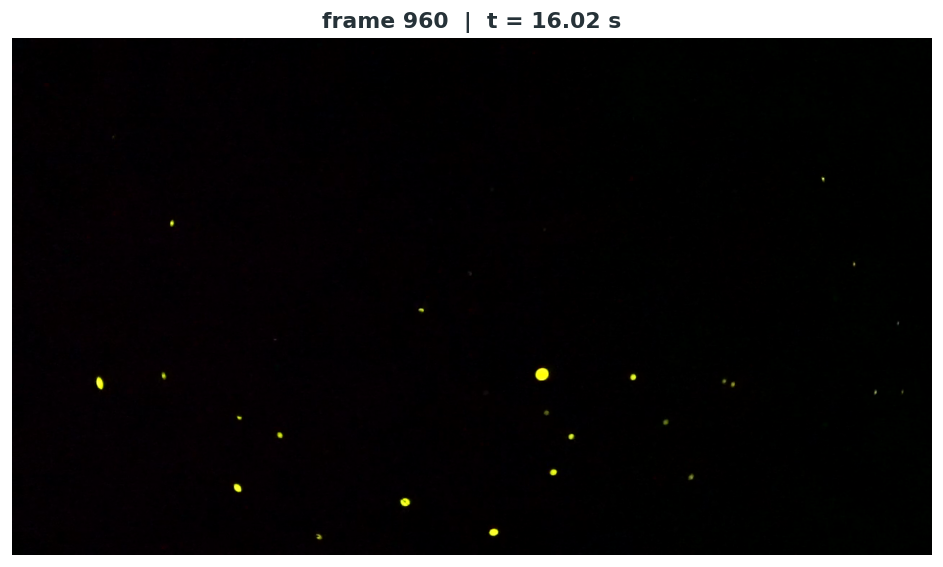

In [3]:
firefly_properties = video_properties(FIREFLY_ANALYSIS_VIDEO)
DEMO_FRAME = 960
demo_rgb = read_rgb_frame(FIREFLY_ANALYSIS_VIDEO, DEMO_FRAME)

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.imshow(demo_rgb)
ax.set_title(
    f"frame {DEMO_FRAME}  |  t = "
    f"{DEMO_FRAME / firefly_properties['fps']:.2f} s"
)
ax.axis("off")
plt.show()


## Threshold bright pixels

$$
\chi_t(x,y)=\mathbf 1_{\{I_t(x,y)>h\}}.
$$



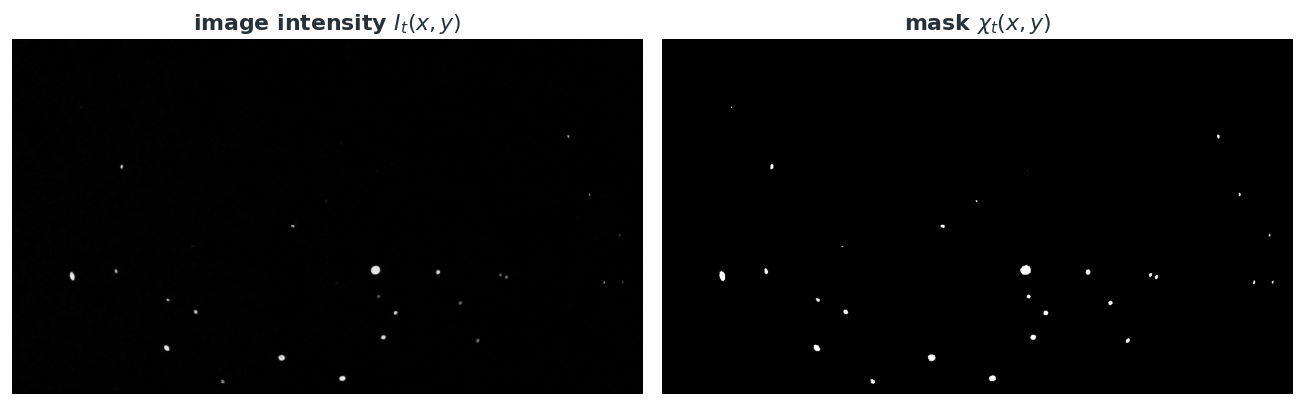

In [4]:
DETECTION_THRESHOLD = 20
demo_gray, demo_mask, demo_labels, demo_components_all = detect_frame(
    demo_rgb,
    threshold=DETECTION_THRESHOLD,
    min_area=5,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(demo_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(r"image intensity $I_t(x,y)$")
axes[1].imshow(demo_mask, cmap="gray")
axes[1].set_title(r"mask $\chi_t(x,y)$")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()


## Group connected pixels

A flash occupies several neighboring pixels. Pixels sharing an edge or corner belong to the same *connected component* $\mathcal C_d$.

For each component $d$, we can calculate its area, total brightness, and centroid position:

$$
a_d=|\mathcal C_d|,
\qquad
I_d=\sum_{(x,y)\in\mathcal C_d}I_t(x,y),
$$

$$
x_d=\frac{1}{a_d}\sum_{(x,y)\in\mathcal C_d}x.
$$

$$
y_d=\frac{1}{a_d}\sum_{(x,y)\in\mathcal C_d}y.
$$


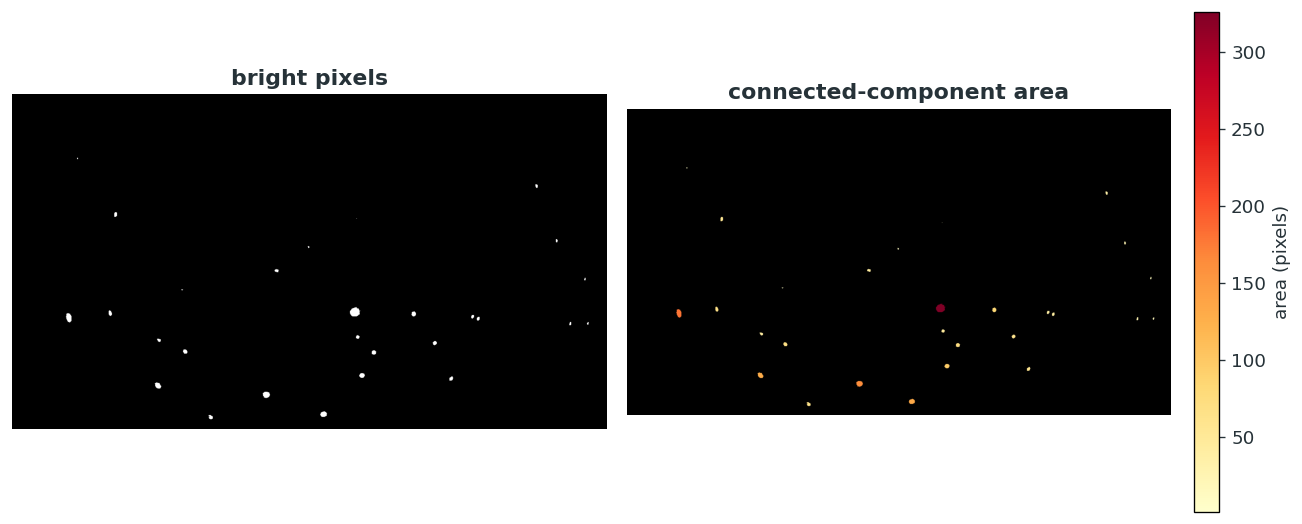

In [5]:
component_areas = np.bincount(demo_labels.ravel())
area_by_pixel = component_areas[demo_labels].astype(float)
area_by_pixel[demo_labels == 0] = np.nan

area_cmap = plt.colormaps["YlOrRd"].copy()
area_cmap.set_bad("black")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(demo_mask, cmap="gray")
axes[0].set_title("bright pixels")
area_image = axes[1].imshow(
    area_by_pixel,
    cmap=area_cmap,
    vmin=1,
    vmax=component_areas[1:].max(),
)
axes[1].set_title("connected-component area")
colorbar = fig.colorbar(
    area_image, ax=axes[1], fraction=0.046, pad=0.04
)
colorbar.set_label("area (pixels)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()


## We will convert each component into an observation

$$
\mathcal D
=\{(x_d,y_d,t_d,I_d,a_d)\}_{d=1}^{n_{\mathrm{det}}}.
$$

Apply the same rule to every frame of the 32-second clip.

In [6]:
firefly_detections, firefly_properties = detect_movie(
    FIREFLY_ANALYSIS_VIDEO,
    threshold=DETECTION_THRESHOLD
)

print(
    f"{firefly_properties['n_frames']:,} frames  →  "
    f"{len(firefly_detections):,} component observations"
)
display(
    firefly_detections.loc[
        firefly_detections["frame"] == DEMO_FRAME
    ]
    .head(8)
    .round({"x_px": 1, "y_px": 1, "time_s": 3})
)


1,918 frames  →  9,153 component observations


,x_px,y_px,frame,time_s,intensity,area
d,,,,,,
4854,140.5,138.0,960,16.016,184,6
4855,1128.1,197.3,960,16.016,2938,33
4856,222.4,258.5,960,16.016,6356,54
4857,1171.3,314.9,960,16.016,1572,23
4858,637.6,328.4,960,16.016,294,11
4859,568.9,379.2,960,16.016,4723,44
4860,1232.1,397.4,960,16.016,720,14
4861,365.5,420.3,960,16.016,217,6


## Each firefly flash spans several frames


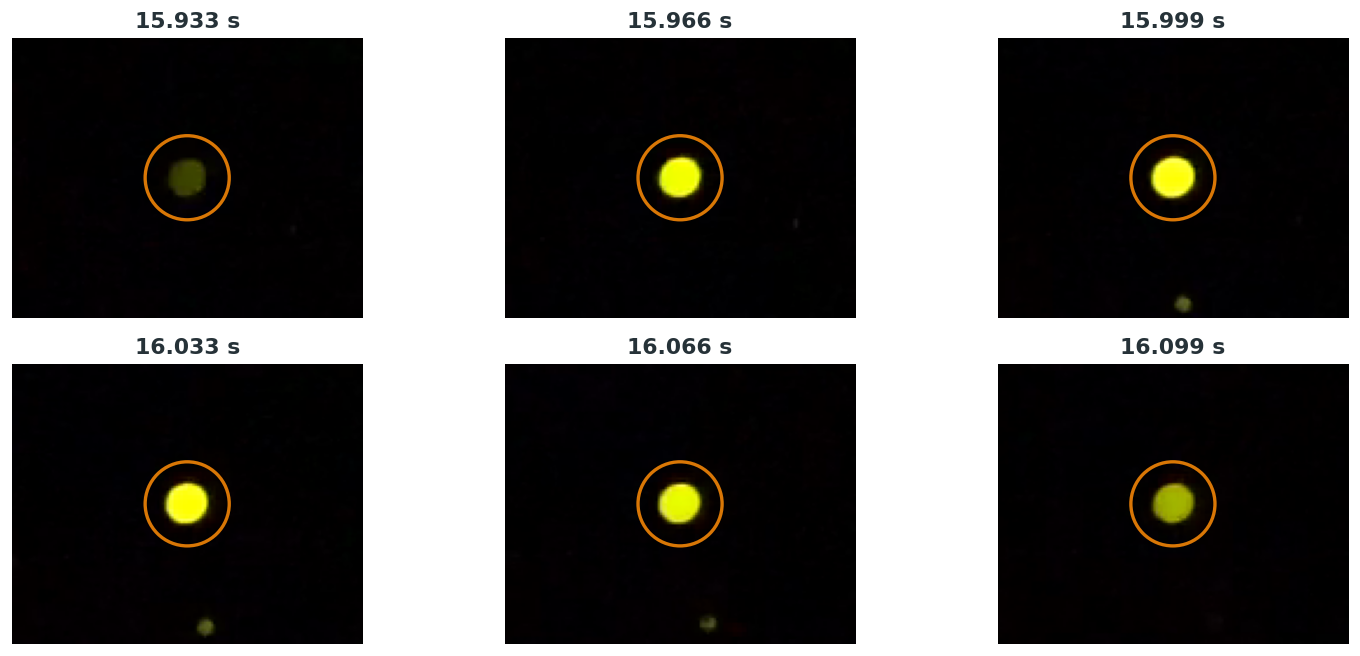

In [7]:
streak_frames = np.arange(955, 966, 2)
reference_rows = firefly_detections.loc[
    firefly_detections["frame"] == DEMO_FRAME
]
reference = reference_rows.loc[reference_rows["intensity"].idxmax()]

fig, axes = plt.subplots(2, 3, figsize=(13, 5.6))
for ax, frame_index in zip(axes.flat, streak_frames):
    frame = read_rgb_frame(FIREFLY_ANALYSIS_VIDEO, frame_index)
    frame_rows = firefly_detections.loc[
        firefly_detections["frame"] == frame_index
    ].copy()
    distance_squared = (
        (frame_rows["x_px"] - reference["x_px"]) ** 2
        + (frame_rows["y_px"] - reference["y_px"]) ** 2
    )
    nearest = frame_rows.loc[distance_squared.idxmin()]
    ax.imshow(frame)
    ax.add_patch(
        Circle(
            (nearest["x_px"], nearest["y_px"]),
            radius=18,
            fill=False,
            color=ORANGE,
            lw=2,
        )
    )
    ax.set_title(f"{frame_index / firefly_properties['fps']:.3f} s")
    ax.set_xlim(nearest["x_px"] - 75, nearest["x_px"] + 75)
    ax.set_ylim(nearest["y_px"] + 60, nearest["y_px"] - 60)
    ax.axis("off")
fig.tight_layout()
plt.show()


## Link observations into flash streaks (tracking)

Between consecutive frames, match each component to at most one successor within

$$
r_{\max}=12\ \text{pixels}.
$$

What sets this length scale?


## Detection rules are measurement choices

The brightness threshold, minimum component area, and $r_{\max}$ are not biological constants. Choose them from image noise, localization uncertainty, and the largest plausible displacement between frames.

Then vary them over a reasonable range. A biological pattern should survive modest changes in the measurement rules.

In [8]:
MAX_LINK_DISTANCE_PX = 12
linked_detections = link_detections(
    firefly_detections,
    max_step_px=MAX_LINK_DISTANCE_PX,
)
streak_summary = make_flash_onset_table(
    linked_detections,
    fps=firefly_properties["fps"],
    min_frames=1,
)


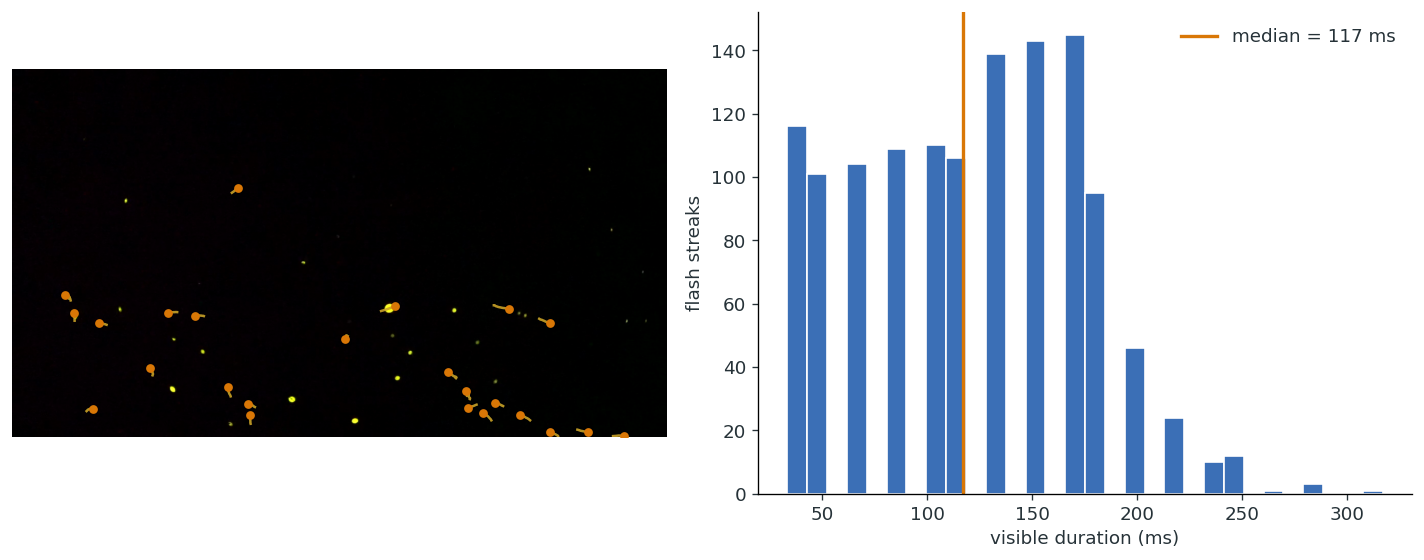

In [9]:
multiframe_streaks = streak_summary.loc[
    streak_summary["duration_frames"] >= 2
]
trajectory_streaks = (
    multiframe_streaks.loc[
        multiframe_streaks["duration_frames"] <= 15
    ]
    .nlargest(24, "path_length_px")["streak"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].imshow(demo_rgb)
for streak_id in trajectory_streaks:
    trajectory = linked_detections.loc[
        linked_detections["streak"] == streak_id
    ].sort_values("frame")
    axes[0].plot(
        trajectory["x_px"], trajectory["y_px"],
        color=GOLD, lw=1.5, alpha=0.9,
    )
    axes[0].scatter(
        trajectory.iloc[0]["x_px"],
        trajectory.iloc[0]["y_px"],
        color=ORANGE, s=18, zorder=3,
    )
axes[0].axis("off")

duration_ms = 1000 * multiframe_streaks["duration_s"]
axes[1].hist(duration_ms, bins=30, color=BLUE, edgecolor="white")
axes[1].axvline(
    duration_ms.median(), color=ORANGE, lw=2,
    label=f"median = {duration_ms.median():.0f} ms",
)
axes[1].set(
    xlabel="visible duration (ms)",
    ylabel="flash streaks",
)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()


## We want to keep track of flash onset

For a streak $\mathcal S_e=(d_{e,1},\ldots,d_{e,m_e})$, define

$$
t_e=t_{d_{e,1}},\qquad m_e\geq 2.
$$

A streak already present in frame 0 has no observed onset and is excluded.


In [10]:
MIN_STREAK_FRAMES = 2
firefly_onsets = make_flash_onset_table(
    linked_detections,
    fps=firefly_properties["fps"],
    min_frames=MIN_STREAK_FRAMES,
)
firefly_onsets = (
    firefly_onsets.loc[firefly_onsets["frame"] > 0]
    .reset_index(drop=True)
)
firefly_onsets.index.name = "e"

print(
    f"{len(firefly_detections):,} component observations  →  "
    f"{len(firefly_onsets):,} flash onsets"
)
display(
    firefly_onsets.head(8).round({
        "x_px": 1, "y_px": 1, "time_s": 3,
        "duration_s": 3, "path_length_px": 1,
    })
)


9,153 component observations  →  1,252 flash onsets


,streak,x_px,y_px,frame,time_s,duration_frames,duration_s,path_length_px
e,,,,,,,,
0,17,920.8,529.1,2,0.033,2,0.033,0.7
1,18,321.8,122.4,3,0.050,9,0.150,5.7
2,19,355.4,179.5,4,0.067,5,0.083,0.7
3,20,335.7,218.9,4,0.067,5,0.083,1.6
4,21,246.0,263.0,4,0.067,9,0.150,1.3
5,22,328.4,302.2,4,0.067,8,0.133,2.6
6,23,466.3,131.5,5,0.083,9,0.150,2.6
7,24,482.4,172.9,5,0.083,6,0.100,3.9


## Count flash onsets in every frame

This is (essentially) the data we looked at in Lecture 2!

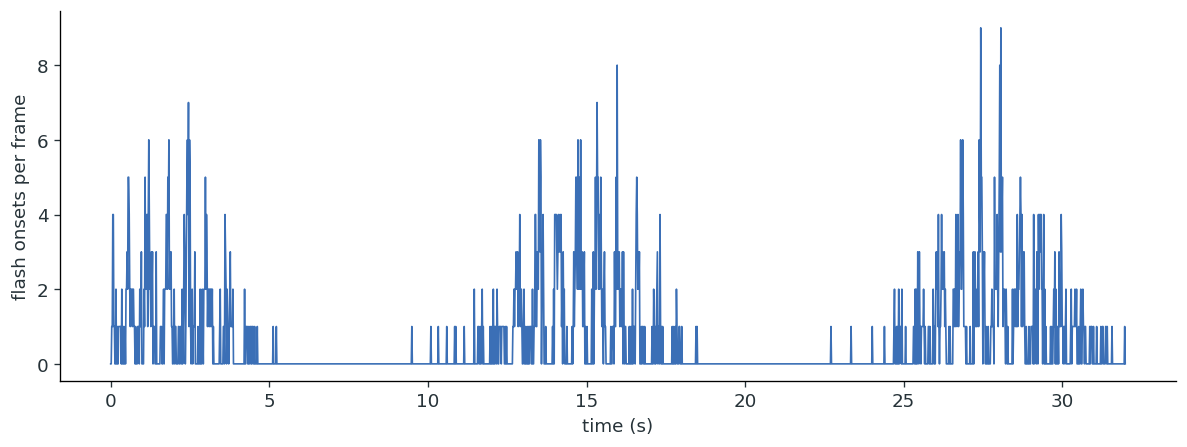

In [11]:
frame_counts = (
    firefly_onsets.groupby("frame")
    .size()
    .reindex(range(firefly_properties["n_frames"]), fill_value=0)
    .to_numpy()
)
firefly_time = np.arange(frame_counts.size) / firefly_properties["fps"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(firefly_time, frame_counts, color=BLUE, lw=1)
ax.set(
    xlabel="time (s)",
    ylabel="flash onsets per frame"
)
plt.show()


## Mouse locomotion

Let's move to a system with a clearer periodic signal so we can explore the Kuramoto model.

In [12]:
movie(MOUSE_VIDEO, width=520)

## Track the four paws

Keypoint pose tracking using CNNs



In [13]:
movie(LEAP_VIDEO, width=960)

## Paw trajectories

We will use the $y$-coordinate (along the body axis) of each paw's displacement.

If we subtract the mean of each, we can see that the four paws are coordinated in their dynamics.

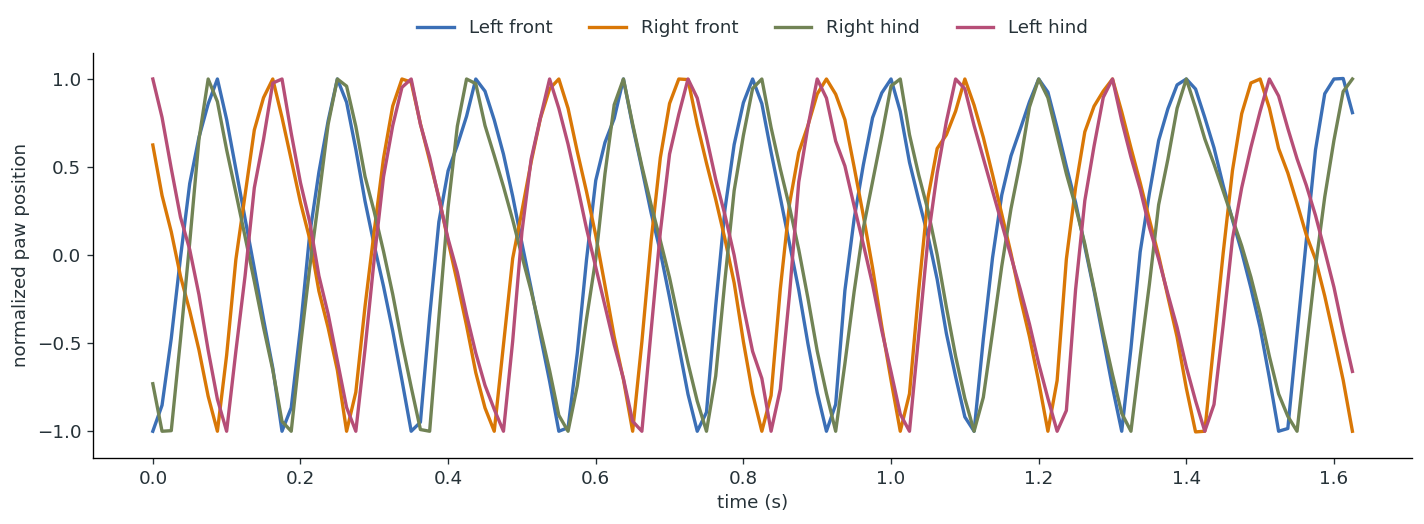

In [14]:
mouse = pd.read_csv(MOUSE_DATA / "mouse-bout-08.csv")
limbs = ["LF", "RF", "RH", "LH"]
paw_names = {
    "LF": "Left front",
    "RF": "Right front",
    "RH": "Right hind",
    "LH": "Left hind",
}
mouse_time = np.arange(len(mouse)) / MOUSE_FPS

fig, ax = plt.subplots(figsize=(12, 4.5))
for limb in limbs:
    ax.plot(
        mouse_time, mouse[limb],
        color=LIMB_COLORS[limb], lw=2, label=paw_names[limb],
    )
ax.set(
    xlabel="time (s)",
    ylabel="normalized paw position",
    ylim=(-1.15, 1.15),
)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    ncol=4, frameon=False, borderaxespad=0,
)
fig.tight_layout()
plt.show()

### Cross-correlation measures temporal offset

We can measure the temporal offset between pairs of paws using the *cross-correlation*.

First center and scale (z-score) each trajectory:

$$
\tilde x_i(t)
=\frac{x_i(t)-\langle x_i(t)\rangle_t}{\sigma_i}.
$$

$\sigma_i$ is the standard deviation of paw $i$'s trajectory over time.

For each trial lag $\tau$, shift the trajectory of paw $j$, multiply the aligned samples, and average over time:

$$
C_{ij}(\tau)
=\left\langle
\tilde x_i(t)\tilde x_j(t+\tau)
\right\rangle_t.
$$

$C_{ij}(\tau)\approx 1$ when the shifted trajectories align and $C_{ij}(\tau)\approx-1$ when they are inverted. 

The lag that best aligns the traces is

$$
\tau_{ij}^{*}=\operatorname*{arg\,max}_{\tau}C_{ij}(\tau).
$$

- positive $\tau_{ij}^{*}$ means paw $j$ follows paw $i$
- a negative value means it leads.

A peak at $\tau=0$ indicates simultaneous motion, while a peak near half a stride time indicates alternation.

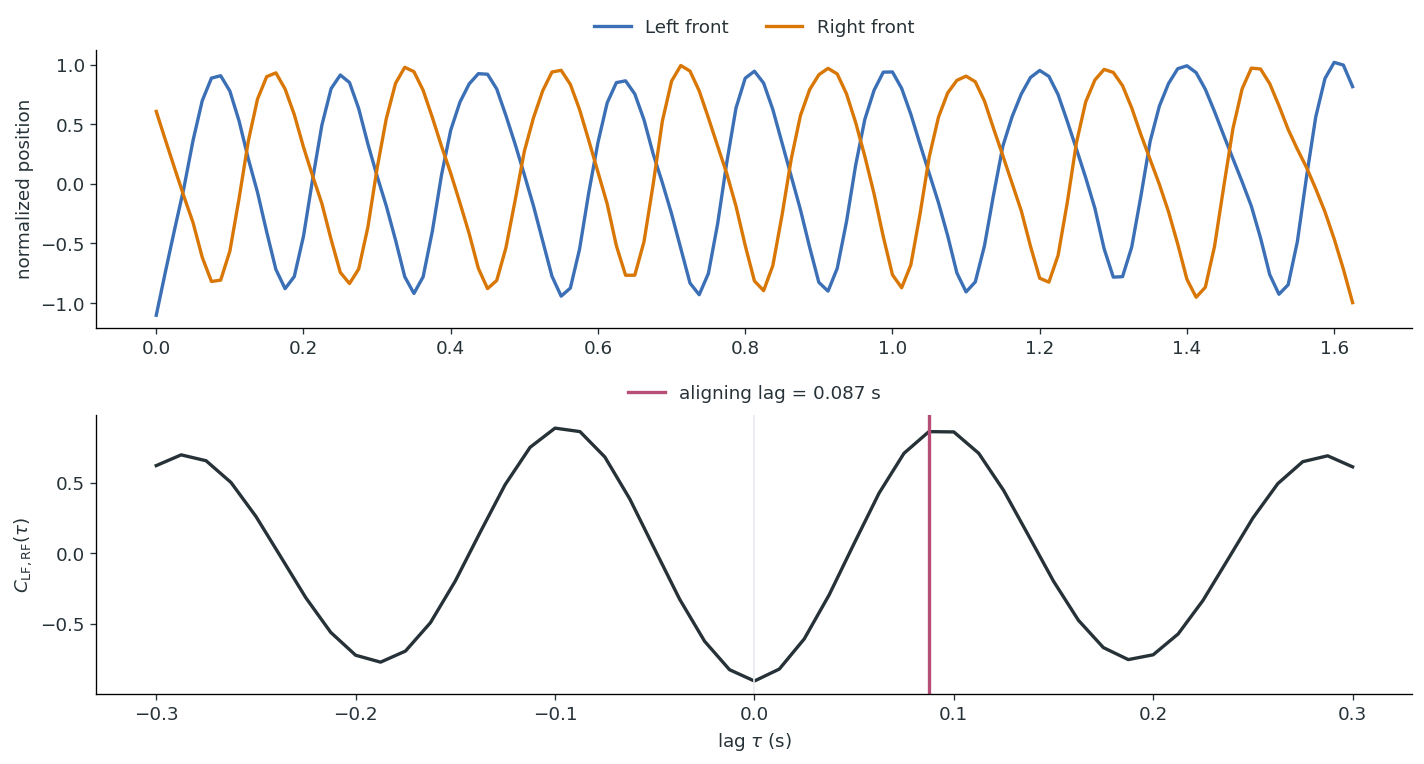

In [15]:
mouse_smoothed = {
    limb: savgol_filter(mouse[limb].to_numpy(), 7, 2)
    for limb in limbs
}

lag_samples, lf_rf_correlation = normalized_cross_correlation(
    mouse_smoothed["LF"], mouse_smoothed["RF"]
)
lag_seconds = lag_samples / MOUSE_FPS
lag_window = np.abs(lag_seconds) <= 0.30
positive_half_cycle = (lag_seconds > 0) & (lag_seconds <= 0.18)
best_positive_lag = lag_seconds[positive_half_cycle][
    np.argmax(lf_rf_correlation[positive_half_cycle])
]

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5))
axes[0].plot(
    mouse_time, mouse_smoothed["LF"],
    color=BLUE, lw=2, label=paw_names["LF"],
)
axes[0].plot(
    mouse_time, mouse_smoothed["RF"],
    color=ORANGE, lw=2, label=paw_names["RF"],
)
axes[0].set(ylabel="normalized position")
axes[0].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    ncol=2, frameon=False, borderaxespad=0,
)

axes[1].plot(
    lag_seconds[lag_window], lf_rf_correlation[lag_window],
    color=INK, lw=2,
)
axes[1].axvline(0, color=LIGHT, lw=1)
axes[1].axvline(
    best_positive_lag, color=PINK, lw=2,
    label=f"aligning lag = {best_positive_lag:.3f} s",
)
axes[1].set(
    xlabel=r"lag $\tau$ (s)",
    ylabel=r"$C_{\rm LF,RF}(\tau)$",
)
axes[1].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    frameon=False, borderaxespad=0,
)
fig.tight_layout()
plt.show()

## Position is not phase

The traces above represent the physical position of the paws in space. As the animal goes through one gait cycle, it repeats the same pattern in space, an *orbit*. 

Because the animal repeats motion around this orbit, we can search for a phase variable that describes where on the orbit the paw is.

## The Hilbert transform

The Hilbert transform can be used to calculate a phase variable for a periodic one-dimensional signal by constructing a second signal in *quadrature* with the first. For example, it turns a cosine into a sine, shifting it by one-quarter period:

$$
x(t)=\cos(\omega t)
\qquad\Longrightarrow\qquad
\mathcal H[x](t)=\sin(\omega t).
$$

For a general (zero-mean centered) signal $x_i(t)$, the Hilbert transform is defined in Fourier space by

$$
\mathcal F\{\mathcal H[x_i](t)\}
=-i\,\operatorname{sgn}(\omega)X_i(\omega),
$$

where $X_i(\omega)=\mathcal F\{x_i(t)\}$.

- Positive-frequency components are multiplied by $-i=e^{-i\pi/2}$, shifting their phase by $-\pi/2$
- Negative-frequency components are multiplied by $+i=e^{i\pi/2}$, shifting their phase by $+\pi/2$. 

The same operation can be written in the time domain as a principal-value integral:

$$
\mathcal H[x_i](t)
=\frac{1}{\pi}\operatorname{PV}\!\int_{-\infty}^{\infty}
\frac{x_i(\tau)}{t-\tau}\,d\tau.
$$

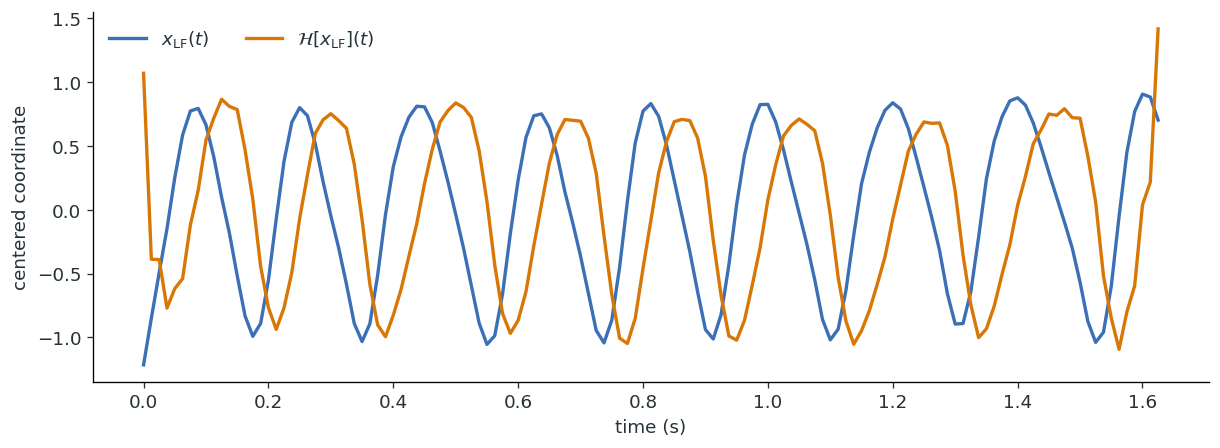

In [16]:
mouse_centered = {
    limb: mouse_smoothed[limb] - np.mean(mouse_smoothed[limb])
    for limb in limbs
}
mouse_analytic = {
    limb: hilbert(mouse_centered[limb])
    for limb in limbs
}

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    mouse_time, mouse_centered["LF"],
    color=BLUE, lw=2, label=r"$x_{\rm LF}(t)$",
)
ax.plot(
    mouse_time, np.imag(mouse_analytic["LF"]),
    color=ORANGE, lw=2, label=r"$\mathcal{H}[x_{\rm LF}](t)$",
)
ax.set(
    xlabel="time (s)",
    ylabel="centered coordinate",
)
ax.legend(frameon=False, ncol=2)
plt.show()

### Phase from the Hilbert transform

At each time $t$, pair the measured signal with its Hilbert transform to construct a point in the complex plane:

$$
\tilde{z}_i(t) = x_i(t) + i \mathcal H[x_i](t)=z_i\ e^{i \theta_i(t)}.
$$

The angle in the complex plane, measured from the positive $x_i$-axis, is the phase we are looking for:

$$
\theta_i(t)
=\operatorname{tan^{-1}}\!\left(\mathcal H[x_i](t),x_i(t)\right).
$$

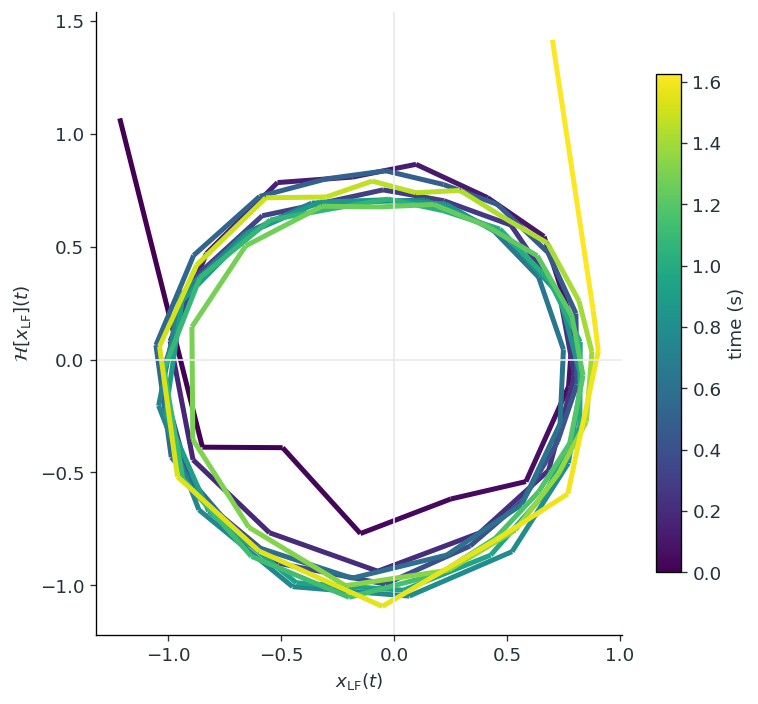

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 6))
line = colored_line(
    ax,
    mouse_centered["LF"],
    np.imag(mouse_analytic["LF"]),
    mouse_time,
    linewidth=3,
)
ax.axhline(0, color=LIGHT, lw=1)
ax.axvline(0, color=LIGHT, lw=1)
ax.set(
    xlabel=r"$x_{\rm LF}(t)$",
    ylabel=r"$\mathcal{H}[x_{\rm LF}](t)$",
)
ax.set_aspect("equal", adjustable="box")
fig.colorbar(line, ax=ax, label="time (s)", shrink=0.8)
fig.tight_layout()
plt.show()

### Phase from $\operatorname{atan2}$

$\operatorname{atan2}$ returns the phase within each cycle between $-\pi$ and $\pi$:

$$
\theta_i(t)
=\operatorname{atan2}\!\left(\mathcal H[x_i](t),x_i(t)\right).
$$

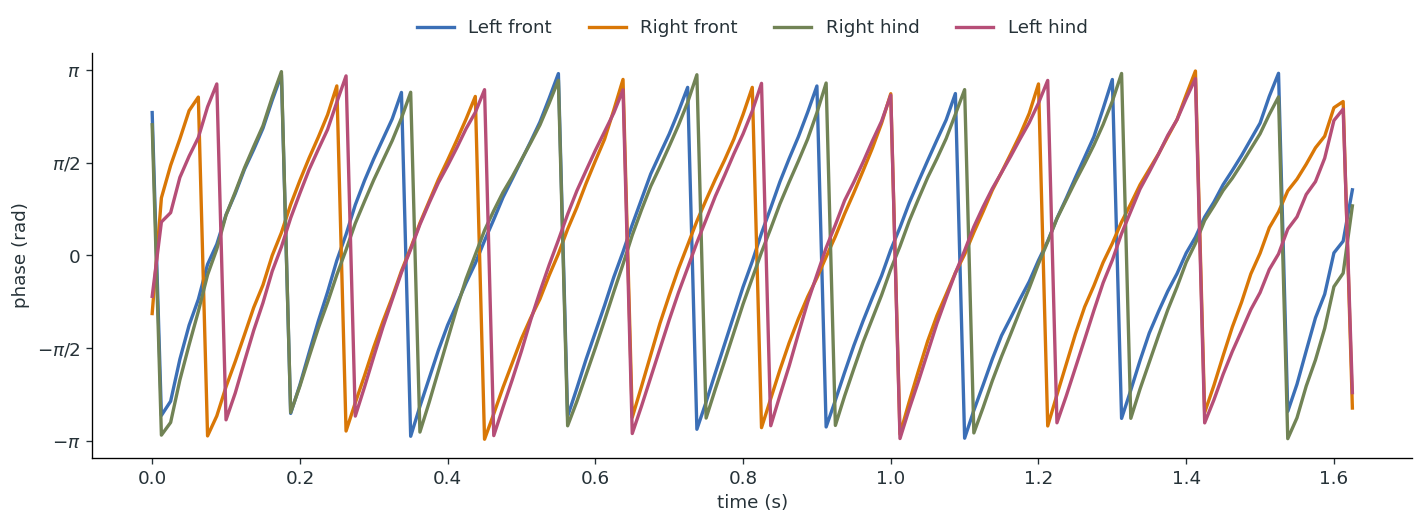

In [18]:
mouse_wrapped_phase = {
    limb: np.arctan2(
        np.imag(mouse_analytic[limb]), mouse_centered[limb]
    )
    for limb in limbs
}

fig, ax = plt.subplots(figsize=(12, 4.5))
for limb in limbs:
    ax.plot(
        mouse_time, mouse_wrapped_phase[limb],
        color=LIMB_COLORS[limb], lw=2, label=paw_names[limb],
    )
ax.set(
    xlabel="time (s)",
    ylabel="phase (rad)",
    yticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    yticklabels=[r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"],
)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    ncol=4, frameon=False, borderaxespad=0,
)
fig.tight_layout()
plt.show()

This is hard to read, and the discontinuities will be a problem for further analysis.

We will *unwrap* the atan2 phases so that the phases keep increasing rather than jumping to $- \pi$.

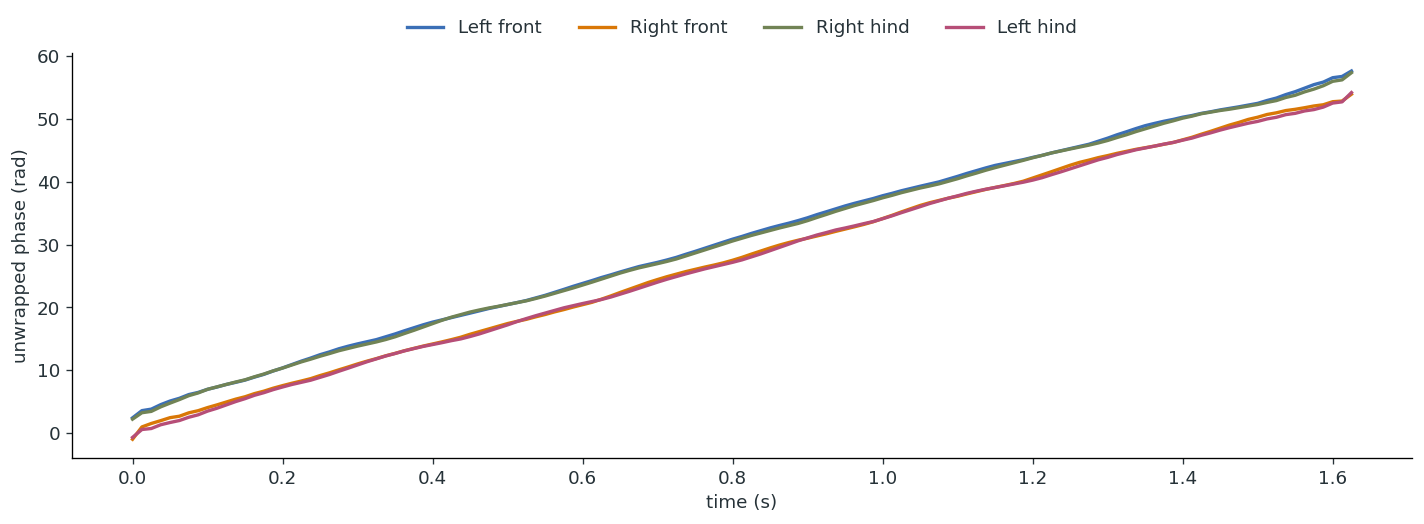

In [19]:
mouse_hilbert_phase = {
    limb: np.unwrap(mouse_wrapped_phase[limb])
    for limb in limbs
}

fig, ax = plt.subplots(figsize=(12, 4.5))
for limb in limbs:
    ax.plot(
        mouse_time, mouse_hilbert_phase[limb],
        color=LIMB_COLORS[limb], lw=2, label=paw_names[limb],
    )
ax.set(
    xlabel="time (s)",
    ylabel="unwrapped phase (rad)",
)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    ncol=4, frameon=False, borderaxespad=0,
)
fig.tight_layout()
plt.show()

### Problems with using the Hilbert transform

The Hilbert Transform only gives you the true phase for pure sine waves.

There are several ways to try to correct for this, none of which are perfect.

My group has designed an RNN-based phase estimator which is much better.

## Quantifying locomotion gait

Four limb phases for the mouse contain three independent differences which define the *gait*. Using LF as the reference:

$$
\phi_{\mathrm{LF},j}(t)
=\theta_j(t)-\theta_{\mathrm{LF}}(t),
\qquad
j\in\{\mathrm{RF},\mathrm{RH},\mathrm{LH}\}.
$$

For each of the 10 locomotion bouts in [`data/mouse/`](../data/mouse/), average the three phase differences over time. Unwrapped phases can differ by integer multiples of $2\pi$, so display each mean on the equivalent branch nearest the ideal trot.

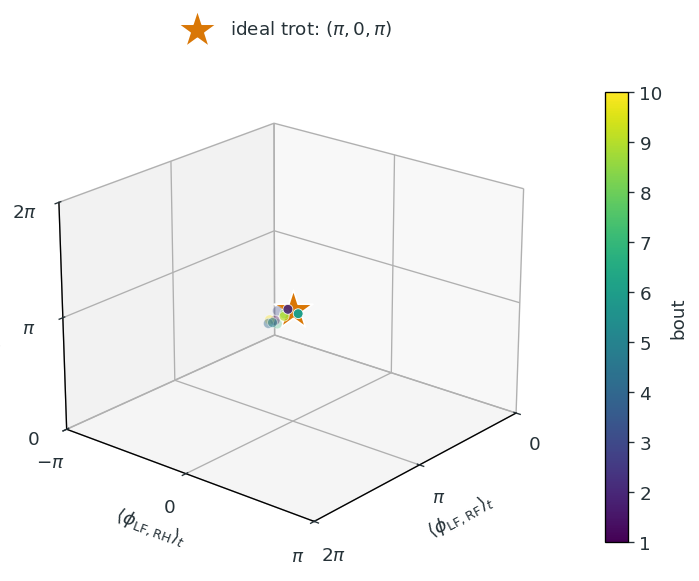

In [20]:
PHASE_EDGE_FRAMES = 10
phase_indices = np.arange(PHASE_EDGE_FRAMES, len(mouse) - PHASE_EDGE_FRAMES)
mouse_paths = sorted(MOUSE_DATA.glob("mouse-bout-*.csv"))
relative_limbs = ["RF", "RH", "LH"]
ideal_trot = np.array([np.pi, 0.0, np.pi])
bout_phase_means = []

for bout_number, path in enumerate(mouse_paths, start=1):
    bout = pd.read_csv(path)
    bout_phase = {}
    for limb in limbs:
        smoothed = savgol_filter(bout[limb].to_numpy(), 7, 2)
        centered = smoothed - np.mean(smoothed)
        quadrature = np.imag(hilbert(centered))
        bout_phase[limb] = np.unwrap(np.arctan2(quadrature, centered))

    bout_indices = np.arange(
        PHASE_EDGE_FRAMES, len(bout) - PHASE_EDGE_FRAMES
    )
    mean_differences = np.array([
        np.mean(
            bout_phase[limb][bout_indices]
            - bout_phase["LF"][bout_indices]
        )
        for limb in relative_limbs
    ])
    # Select the equivalent 2π branch nearest the ideal trot.
    mean_differences += TAU * np.round(
        (ideal_trot - mean_differences) / TAU
    )
    bout_phase_means.append([bout_number, *mean_differences])

bout_phase_means = pd.DataFrame(
    bout_phase_means, columns=["bout", *relative_limbs]
)

fig = plt.figure(figsize=(8, 6.5))
ax = fig.add_subplot(111, projection="3d")
points = ax.scatter(
    bout_phase_means["RF"],
    bout_phase_means["RH"],
    bout_phase_means["LH"],
    c=bout_phase_means["bout"], cmap="viridis",
    s=35, edgecolor="white", linewidth=0.5,
)
ax.scatter(
    *ideal_trot, marker="*", s=600, color=ORANGE,
    edgecolor="white", label=r"ideal trot: $(\pi,0,\pi)$",
)
ax.set(
    xlabel=r"$\langle\phi_{\rm LF,RF}\rangle_t$",
    ylabel=r"$\langle\phi_{\rm LF,RH}\rangle_t$",
    zlabel=r"$\langle\phi_{\rm LF,LH}\rangle_t$",
    xlim=(0, TAU), ylim=(-np.pi, np.pi), zlim=(0, TAU),
    xticks=[0, np.pi, TAU],
    yticks=[-np.pi, 0, np.pi],
    zticks=[0, np.pi, TAU],
    xticklabels=["0", r"$\pi$", r"$2\pi$"],
    yticklabels=[r"$-\pi$", "0", r"$\pi$"],
    zticklabels=["0", r"$\pi$", r"$2\pi$"],
)
ax.view_init(elev=22, azim=40)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False,
)
fig.colorbar(
    points, ax=ax, label="bout", ticks=range(1, 11),
    pad=0.10, shrink=0.75,
)
fig.subplots_adjust(left=0.12, right=0.82)
plt.show()

The gait is nearly an ideal trot, which has phase offsets $(-\pi,0,-\pi)$.

- diagonal paws move together (in phase)
- opposite diagonals alternate (out of phase).

## A trot exposes the limit of $R$

The Kuramoto order parameter $R$ measures concentration around one phase. In an ideal trot, two paws at phase $\theta$ and two at $\theta+\pi$ cancel, giving $R=0$ even though the gait is perfectly organized.

Pairwise relative phases reveal that organization. PLV asks whether each phase difference stays fixed, whether that fixed difference is $0$, $\pi$, or something else.

## Quantifying synchronization

The *phase-locking value* measures how constant the phase differences are over time, ranging from 0 to 1:

$$
\mathrm{PLV}_{ij}
=\left|
\left\langle e^{i\phi_{ij}(t)}\right\rangle_t
\right|.
$$

For the mouse data, PLV is very high.

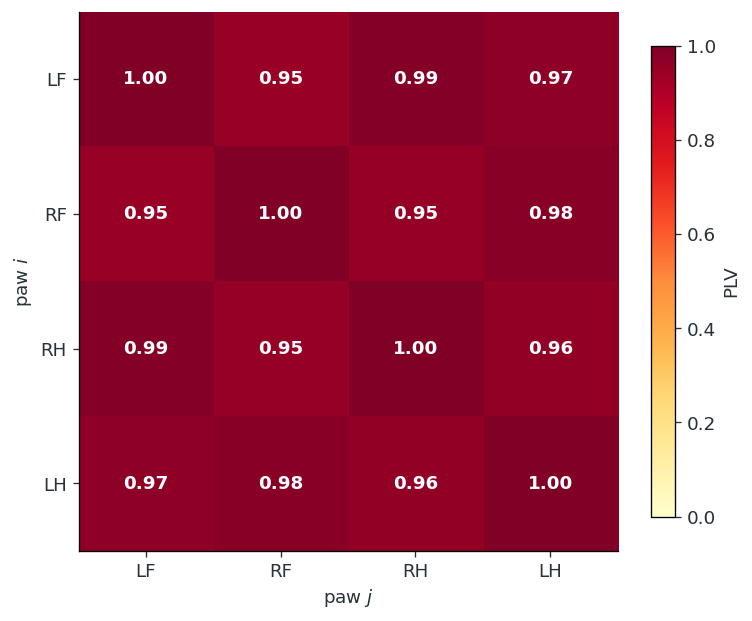

In [21]:
plv_matrix = np.eye(len(limbs))
for i, limb_i in enumerate(limbs):
    for j, limb_j in enumerate(limbs):
        phase_difference = (
            mouse_hilbert_phase[limb_j][phase_indices]
            - mouse_hilbert_phase[limb_i][phase_indices]
        )
        plv_matrix[i, j] = np.abs(np.mean(np.exp(1j * phase_difference)))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(plv_matrix, cmap="YlOrRd", vmin=0, vmax=1)
for i in range(len(limbs)):
    for j in range(len(limbs)):
        ax.text(
            j, i, f"{plv_matrix[i, j]:.2f}",
            ha="center", va="center",
            color="white" if plv_matrix[i, j] > 0.72 else INK,
            fontweight="bold",
        )
ax.set(
    xticks=range(len(limbs)), yticks=range(len(limbs)),
    xticklabels=limbs, yticklabels=limbs,
    xlabel="paw $j$", ylabel="paw $i$",
)
fig.colorbar(image, ax=ax, label="PLV", shrink=0.82)
fig.tight_layout()
plt.show()

## Fit phase dynamics, not only phase order

With these phases, we can directly fit a phase-coupling model:

$$
\frac{d\theta_i}{dt}
=\omega_i
+\sum_{j\ne i}\alpha_{ij}
\sin\!\left(
\theta_i
-\theta_j
-\psi_{ij}
\right)
$$

$\alpha_{ij}$ is the coupling from paw $j$ to paw $i$, and $\psi_{ij}$ shifts that interaction in phase. To use linear least squares, rewrite each interaction as

$$
\alpha_{ij}\sin(\theta_i-\theta_j-\psi_{ij})
=a_{ij}\sin(\theta_i-\theta_j)
+b_{ij}\cos(\theta_i-\theta_j),
$$

where $a_{ij}=\alpha_{ij}\cos\psi_{ij}$ and $b_{ij}=-\alpha_{ij}\sin\psi_{ij}$. Infer the Hilbert phase and its velocity separately within each bout, discard ten edge frames, then combine the interior samples from all ten bouts.

In [22]:
FIT_EDGE_FRAMES = 10
PHASE_DERIVATIVE_WINDOW = 11
PHASE_DERIVATIVE_ORDER = 3

fit_phase_chunks = []
fit_velocity_chunks = []
fit_bout_chunks = []

for bout_number, path in enumerate(mouse_paths, start=1):
    bout = pd.read_csv(path)
    bout_phase = []

    for limb in limbs:
        smoothed = savgol_filter(bout[limb].to_numpy(), 7, 2)
        centered = smoothed - np.mean(smoothed)
        bout_phase.append(
            np.unwrap(np.angle(hilbert(centered)))
        )

    bout_phase = np.column_stack(bout_phase)
    bout_velocity = savgol_filter(
        bout_phase,
        PHASE_DERIVATIVE_WINDOW,
        PHASE_DERIVATIVE_ORDER,
        deriv=1,
        delta=1 / MOUSE_FPS,
        axis=0,
    )
    interior = np.arange(
        FIT_EDGE_FRAMES, len(bout) - FIT_EDGE_FRAMES
    )
    fit_phase_chunks.append(bout_phase[interior])
    fit_velocity_chunks.append(bout_velocity[interior])
    fit_bout_chunks.append(
        np.full(interior.size, bout_number, dtype=int)
    )

fit_phase = np.vstack(fit_phase_chunks)
fit_velocity = np.vstack(fit_velocity_chunks)
fit_bout = np.concatenate(fit_bout_chunks)

n_limbs = len(limbs)
omega = np.zeros(n_limbs)
alpha = np.full((n_limbs, n_limbs), np.nan)
psi = np.full((n_limbs, n_limbs), np.nan)
predicted_velocity = np.zeros_like(fit_velocity)
fit_r_squared = np.zeros(n_limbs)
fit_condition_number = np.zeros(n_limbs)

for i in range(n_limbs):
    source_indices = [j for j in range(n_limbs) if j != i]
    phase_differences = (
        fit_phase[:, [i]] - fit_phase[:, source_indices]
    )
    design = np.column_stack([
        np.ones(len(fit_phase)),
        np.sin(phase_differences),
        np.cos(phase_differences),
    ])
    coefficients, _, rank, _ = np.linalg.lstsq(
        design, fit_velocity[:, i], rcond=None
    )
    if rank != design.shape[1]:
        raise RuntimeError(f"Rank-deficient fit for {limbs[i]}")

    omega[i] = coefficients[0]
    sine_coefficients = coefficients[1:n_limbs]
    cosine_coefficients = coefficients[n_limbs:]
    predicted_velocity[:, i] = design @ coefficients
    fit_condition_number[i] = np.linalg.cond(design)

    residual_sum_squares = np.sum(
        (fit_velocity[:, i] - predicted_velocity[:, i]) ** 2
    )
    total_sum_squares = np.sum(
        (fit_velocity[:, i] - np.mean(fit_velocity[:, i])) ** 2
    )
    fit_r_squared[i] = 1 - residual_sum_squares / total_sum_squares

    for coefficient_index, j in enumerate(source_indices):
        alpha[i, j] = np.hypot(
            sine_coefficients[coefficient_index],
            cosine_coefficients[coefficient_index],
        )
        psi[i, j] = np.arctan2(
            -cosine_coefficients[coefficient_index],
            sine_coefficients[coefficient_index],
        )

reconstructed_velocity = np.tile(omega, (len(fit_phase), 1))
for i in range(n_limbs):
    for j in range(n_limbs):
        if i != j:
            reconstructed_velocity[:, i] += alpha[i, j] * np.sin(
                fit_phase[:, i] - fit_phase[:, j] - psi[i, j]
            )
assert np.allclose(reconstructed_velocity, predicted_velocity)

fit_summary = pd.DataFrame({
    "paw": [paw_names[limb] for limb in limbs],
    "omega_i (rad/s)": omega,
    "R²": fit_r_squared,
    "condition number": fit_condition_number,
})
print(
    f"Fit {n_limbs} equations to {len(fit_phase):,} time points "
    f"from {len(mouse_paths)} bouts."
)
display(fit_summary.round(2))

Fit 4 equations to 1,771 time points from 10 bouts.


,paw,omega_i (rad/s),R²,condition number
0,Left front,17.56,0.20,27.07
1,Right front,22.61,0.12,34.67
2,Right hind,14.19,0.20,28.63
3,Left hind,20.51,0.19,35.39


## Fitted interactions

Each bar is a directed pair: the arrow points from the source paw $j$ to the target paw $i$. Bar height and color both encode the fitted value.

We can try to fit our 10 bouts to this model ...

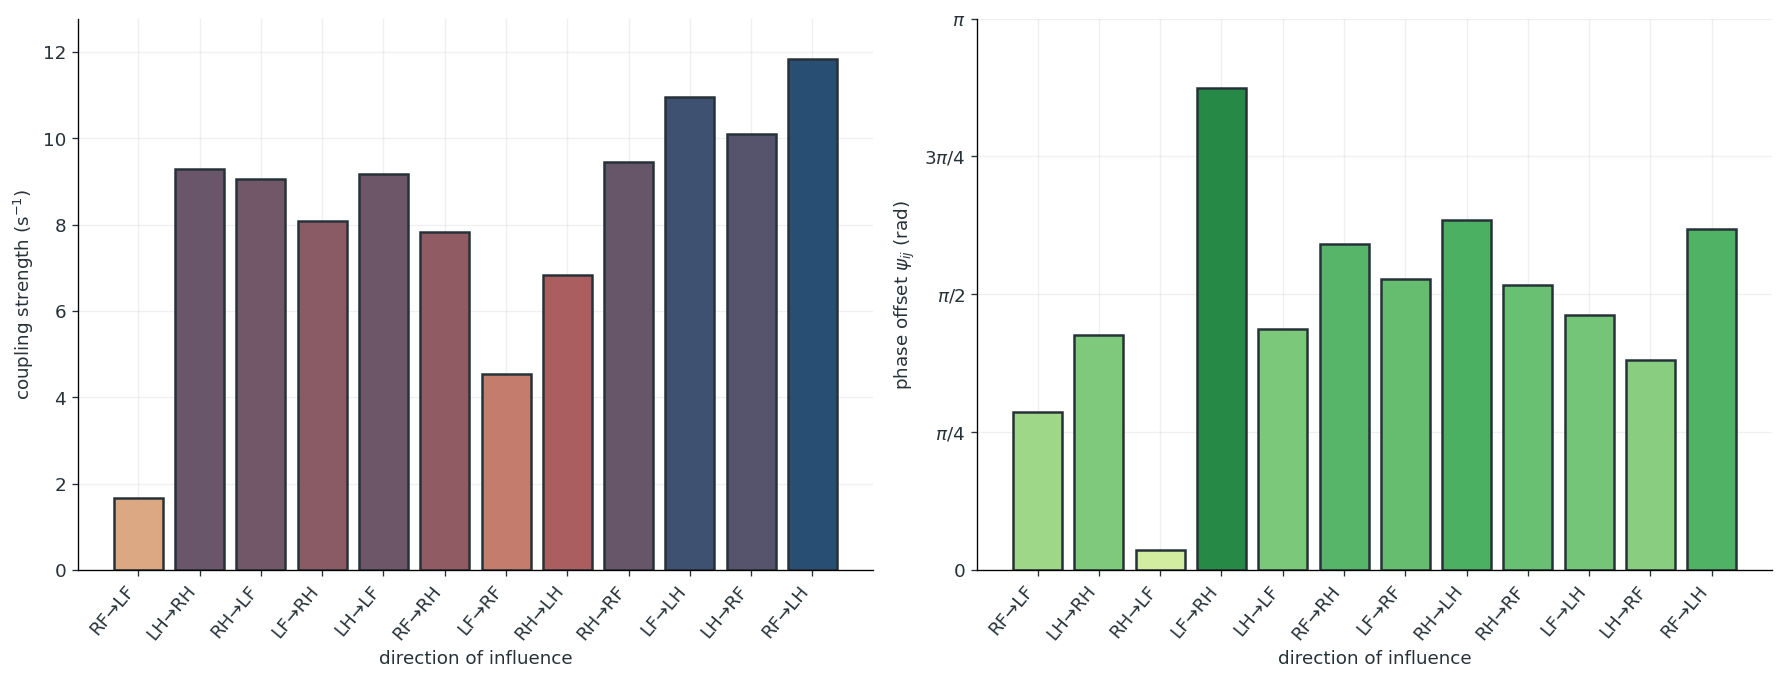

In [23]:
pair_order = [
    (0, 1), (2, 3), (0, 2), (2, 0), (0, 3), (2, 1),
    (1, 0), (3, 2), (1, 2), (3, 0), (1, 3), (3, 1),
]
pair_labels = [f"{limbs[j]}→{limbs[i]}" for i, j in pair_order]
coupling_strengths = np.array([alpha[i, j] for i, j in pair_order])
phase_offsets = np.array([psi[i, j] for i, j in pair_order])
alpha_cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "alpha_strength",
    [(0.0, "#E8C18F"), (0.55, "#B45F5F"), (1.0, "#294E73")],
)
alpha_norm = plt.Normalize(0, np.max(coupling_strengths))
alpha_colors = alpha_cmap(alpha_norm(coupling_strengths))

psi_norm = plt.Normalize(0, np.pi)
psi_colors = plt.colormaps["YlGn"](
    0.25 + 0.55 * psi_norm(phase_offsets)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
axes[0].bar(
    pair_labels, coupling_strengths,
    color=alpha_colors, edgecolor=INK, linewidth=1.5,
)
axes[0].set(
    xlabel="direction of influence",
    ylabel=r"coupling strength (s$^{-1}$)",
    ylim=(0, 1.08 * np.max(coupling_strengths)),
)

axes[1].bar(
    pair_labels, phase_offsets,
    color=psi_colors, edgecolor=INK, linewidth=1.5,
)
axes[1].set(
    xlabel="direction of influence",
    ylabel=r"phase offset $\psi_{ij}$ (rad)",
    ylim=(0, np.pi),
    yticks=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi],
    yticklabels=["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"],
)

for ax in axes:
    ax.tick_params(axis="x", rotation=50)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    ax.grid(alpha=0.18)
    ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

... but unfortunately that is a very small amount of data and our fit only explains 15% of the data.

To do this properly, we use 30,000 bouts containing >2 million data points.

<div style="display: flex; gap: 1rem; align-items: flex-start;">
  <img src="../media/mouse-coupling-fit-small-dataset.png" style="width: 49%; height: auto;">
  <img src="../media/mouse-coupling-fit-large-dataset.png" style="width: 49%; height: auto;">
</div>


## Sources

- Raphael Sarfati, Julie C. Hayes, and Orit Peleg, [“Self-organization in natural swarms of *Photinus carolinus* synchronous fireflies”](https://doi.org/10.1126/sciadv.abg9259), *Science Advances* 7 (2021).
- Talmo D. Pereira *et al.*, [“SLEAP: A deep learning system for multi-animal pose tracking”](https://doi.org/10.1038/s41592-022-01426-1), *Nature Methods* 19 (2022).
- Shai Revzen and John M. Guckenheimer, [“Estimating the phase of synchronized oscillators”](https://doi.org/10.1103/PhysRevE.78.051907), *Physical Review E* 78, 051907 (2008).
- Arkady Pikovsky, Michael Rosenblum, and Jürgen Kurths, *Synchronization: A Universal Concept in Nonlinear Sciences* (2001).